# Import libraries

In [99]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score
)

# Import data

In [100]:
# import the dataset
df = pd.read_csv(r"C:\Users\MOSHOOD\Desktop\3MTT\LRA\Invistico_Airline.csv.csv")

df.head()

,satisfaction,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,2,...,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,3,...,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,3,...,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,3,...,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,3,...,4,2,2,0,2,4,2,5,0,0.0


In [101]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 22 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   satisfaction                       129880 non-null  str    
 1   Customer Type                      129880 non-null  str    
 2   Age                                129880 non-null  int64  
 3   Type of Travel                     129880 non-null  str    
 4   Class                              129880 non-null  str    
 5   Flight Distance                    129880 non-null  int64  
 6   Seat comfort                       129880 non-null  int64  
 7   Departure/Arrival time convenient  129880 non-null  int64  
 8   Food and drink                     129880 non-null  int64  
 9   Gate location                      129880 non-null  int64  
 10  Inflight wifi service              129880 non-null  int64  
 11  Inflight entertainment             129880 non-null

In [102]:
df.describe(include='all')

,satisfaction,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
count,129880,129880,129880.000000,129880,129880,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,...,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129487.000000
unique,2,2,NaN,2,3,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,satisfied,Loyal Customer,NaN,Business travel,Business,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,71087,106100,NaN,89693,62160,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,39.427957,NaN,NaN,1981.409055,2.838597,2.990645,2.851994,2.990422,...,3.519703,3.472105,3.465075,3.485902,3.695673,3.340807,3.705759,3.352587,14.713713,15.091129
std,NaN,NaN,15.119360,NaN,NaN,1027.115606,1.392983,1.527224,1.443729,1.305970,...,1.306511,1.305560,1.270836,1.292226,1.156483,1.260582,1.151774,1.298715,38.071126,38.465650
min,NaN,NaN,7.000000,NaN,NaN,50.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,27.000000,NaN,NaN,1359.000000,2.000000,2.000000,2.000000,2.000000,...,3.000000,2.000000,3.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,NaN,NaN,40.000000,NaN,NaN,1925.000000,3.000000,3.000000,3.000000,3.000000,...,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,4.000000,0.000000,0.000000
75%,NaN,NaN,51.000000,NaN,NaN,2544.000000,4.000000,4.000000,4.000000,4.000000,...,5.000000,5.000000,4.000000,5.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000


# Data Cleaning

In [103]:
df.isnull().sum()

satisfaction                           0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Seat comfort                           0
Departure/Arrival time convenient      0
Food and drink                         0
Gate location                          0
Inflight wifi service                  0
Inflight entertainment                 0
Online support                         0
Ease of Online booking                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Cleanliness                            0
Online boarding                        0
Departure Delay in Minutes             0
Arrival Delay in Minutes             393
dtype: int64

In [104]:
df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].fillna(
    df['Arrival Delay in Minutes'].median()
)

The arrival delay time contain 393 missing , this was handle by fill them with median value of the overrall datasets

# Inspect Target Variable

In [105]:
df['satisfaction'].value_counts()

satisfaction
satisfied       71087
dissatisfied    58793
Name: count, dtype: int64

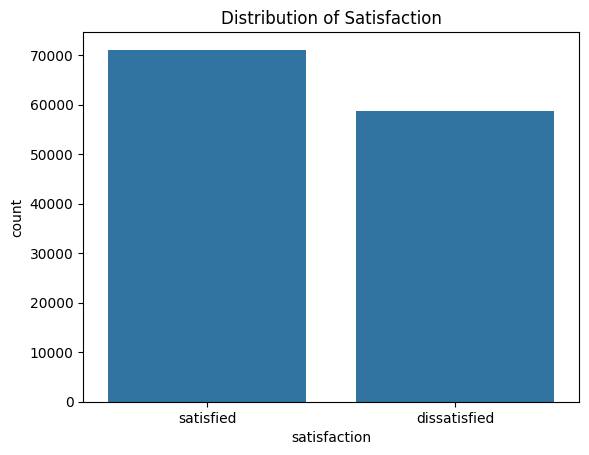

In [106]:
sns.countplot(x='satisfaction', data=df)
plt.title("Distribution of Satisfaction")
plt.show()

The target column that used to classify the customer satistifaction contain 71087 cutomer that satisfy with airline service while 58793 did not satify with the service of the airline service.

# Encode the Variables

In [107]:
le = LabelEncoder()

df['satisfaction'] = le.fit_transform(df['satisfaction'])

In [108]:
original_df = pd.read_csv(r"C:\Users\MOSHOOD\Desktop\3MTT\LRA\Invistico_Airline.csv.csv")

In [109]:
from sklearn.preprocessing import LabelEncoder

for col in ['Customer Type', 'Type of Travel', 'Class']:
    le = LabelEncoder()
    le.fit(original_df[col])

    print(f"\n{col}")
    for label, code in zip(le.classes_, le.transform(le.classes_)):
        print(f"{label} --> {code}")


Customer Type
Loyal Customer --> 0
disloyal Customer --> 1

Type of Travel
Business travel --> 0
Personal Travel --> 1

Class
Business --> 0
Eco --> 1
Eco Plus --> 2


# Encode Categorical Features

In [110]:
df.select_dtypes(include='object').columns

C:\Users\MOSHOOD\AppData\Local\Temp\ipykernel_1936\3732952691.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').columns


Index(['Customer Type', 'Type of Travel', 'Class'], dtype='str')

In [111]:
categorical = df.select_dtypes(include='object').columns

for col in categorical:
    df[col] = LabelEncoder().fit_transform(df[col])

C:\Users\MOSHOOD\AppData\Local\Temp\ipykernel_1936\3111803211.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical = df.select_dtypes(include='object').columns


# Feature Selection

In [112]:
X = df.drop('satisfaction', axis=1)

y = df['satisfaction']

# Train-Test Split

In [113]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Logistic Regression Model

In [114]:
# Split the data
X = df.drop('satisfaction', axis=1)
y = df['satisfaction']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Scale the features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train the model
model = LogisticRegression(max_iter=5000)

model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",5000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

The Logistic Regression model was successfully trained using the standardized training dataset. Before fitting the model, the data was divided into training (80%) and testing (20%) sets to ensure that model performance could be evaluated on unseen data. Feature scaling was performed using `StandardScaler` to place all predictor variables on a comparable scale, which improves the convergence and stability of the Logistic Regression algorithm.
The model converged successfully within the specified maximum number of iterations (`max_iter=5000`), indicating that the optimization process found a stable set of coefficients for predicting passenger satisfaction. At this stage, the model has learned the relationship between the predictor variables and the target variable (`satisfaction`) and is ready to make predictions on the test dataset. 


# Predictions

In [115]:
y_pred = model.predict(X_test)

In [116]:
y_prob = model.predict_proba(X_test)

y_prob[:10]

array([[0.07525387, 0.92474613],
       [0.93300399, 0.06699601],
       [0.16941293, 0.83058707],
       [0.20956885, 0.79043115],
       [0.79965525, 0.20034475],
       [0.19009253, 0.80990747],
       [0.96697993, 0.03302007],
       [0.32825807, 0.67174193],
       [0.04468297, 0.95531703],
       [0.66289111, 0.33710889]])

The output above displays the predicted probabilities of each passenger belonging to the two satisfaction classes. Each row corresponds to a passenger in the test dataset, where the first value represents the probability of the passenger being Dissatisfied (Class 0) and the second value represents the probability of the passenger being Satisfied (Class 1).
For example, the first passenger has a 7.53% probability of being Dissatisfied and a 92.47% probability of being Satisfied. Since the probability of being Satisfied is greater than 50%, the model classifies this passenger as Satisfied. Similarly, the second passenger has a 93.30% probability of being Dissatisfied and only a 6.70% probability of being Satisfied, so the model predicts this passenger as Dissatisfied. These probability estimates provide more information than the predicted class labels alone, as they indicate the model's level of confidence in each prediction.

In [117]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8257622420696027


The Logistic Regression model achieved an **accuracy of 82.58%**, indicating that it correctly classified approximately **83 out of every 100 passengers** in the test dataset. This suggests that the model has a good overall ability to distinguish between satisfied and neutral/dissatisfied passengers.
While the accuracy indicates strong predictive performance, it should not be used as the sole measure of model effectiveness. In classification problems, accuracy alone may not fully capture the model's performance, particularly if the classes are imbalanced. Therefore, additional evaluation metrics such as **Precision**, **Recall**, **F1-score**, and the **Confusion Matrix** are also examined to provide a more comprehensive assessment of the model's ability to correctly identify satisfied and dissatisfied passengers.


In [118]:
recall = recall_score(y_test, y_pred)

print("Recall:", recall)

Recall: 0.8408502901894972


**Interpretation**
The Logistic Regression model achieved a **recall of 84.09%**, meaning that it correctly identified approximately **84 out of every 100 passengers who were actually satisfied**. In other words, the model successfully detected the majority of satisfied passengers while missing only a relatively small proportion.
A high recall is important in this context because it indicates that the model is effective at recognizing satisfied customers. This enables the airline to better understand the characteristics associated with customer satisfaction and to accurately identify passengers who are likely to have had a positive travel experience.
Although the recall value is high, it should be interpreted alongside **precision** to ensure that the model not only identifies most satisfied passengers but also minimizes incorrect positive predictions. Together with the Confusion Matrix and other evaluation metrics, recall provides a more comprehensive assessment of the model's classification performance.


In [119]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.81      0.81     11675
           1       0.84      0.84      0.84     14301

    accuracy                           0.83     25976
   macro avg       0.82      0.82      0.82     25976
weighted avg       0.83      0.83      0.83     25976



The classification report provides a comprehensive evaluation of the Logistic Regression model by summarizing its **precision**, **recall**, **F1-score**, and the number of observations (**support**) for each class.
For **Class 0 (Neutral or Dissatisfied)**, the model achieved a **precision of 81%**, indicating that when it predicted a passenger as neutral or dissatisfied, the prediction was correct 81% of the time. It also achieved a **recall of 81%**, meaning that it correctly identified 81% of all passengers who were actually neutral or dissatisfied. The **F1-score of 81%** demonstrates a balanced performance between precision and recall for this class.
For **Class 1 (Satisfied)**, the model achieved both a **precision and recall of 84%**, indicating that it reliably identifies satisfied passengers while correctly capturing most of the actual satisfied cases. The corresponding **F1-score of 84%** confirms a strong balance between prediction accuracy and the ability to detect satisfied passengers.
The model achieved an overall **accuracy of 82.58%**, demonstrating good classification performance across the test dataset. Additionally, the **macro average** values of **82%** indicate that the model performs consistently across both classes without being overly influenced by the larger class. The **weighted average** values of **83%** further confirm that the model maintains strong overall performance while accounting for the class distribution.
Overall, the classification report suggests that the Logistic Regression model is effective at distinguishing between satisfied and neutral/dissatisfied passengers, with slightly stronger performance in identifying satisfied passengers. These results indicate that the model is reliable for supporting customer satisfaction analysis and can provide valuable insights for improving airline service quality and customer retention strategies.

# Confusion Matrix

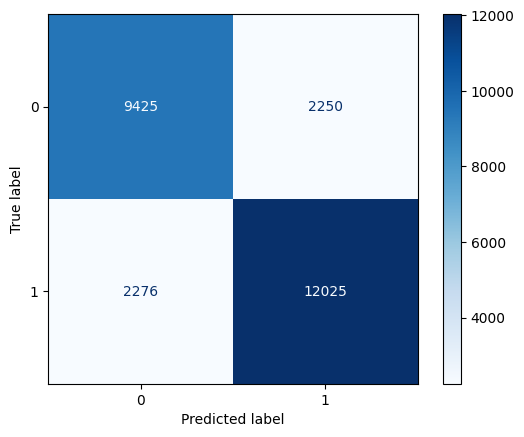

In [120]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap='Blues')

plt.show()

The model correctly classified 9,425 passengers as Dissatisfied (True Negatives) and 12,025 passengers as Satisfied (True Positives). These correct classifications account for the majority of the test observations, demonstrating that the model effectively distinguishes between the two satisfaction classes.
However, the model also made some misclassifications. It incorrectly predicted 2,250 passengers as Satisfied when they were actually Neutral or Dissatisfied (False Positives). In addition, 2,276 passengers who were actually Satisfied were incorrectly classified as Neutral or Dissatisfied (False Negatives).
Overall, the confusion matrix indicates that the model performs well, correctly classifying 21,450 out of 25,976 passengers, which corresponds to an overall accuracy of approximately 82.58%. The relatively balanced number of false positives and false negatives suggests that the model does not exhibit a strong bias toward either class. This balanced performance is consistent with the model's precision, recall, and F1-score, indicating that it provides reliable predictions for identifying both satisfied and neutral/dissatisfied passengers.

# Interpret Coefficients

In [121]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

coefficients.sort_values(
    by='Coefficient',
    ascending=False
)

,Feature,Coefficient
10,Inflight entertainment,0.984318
13,On-board service,0.405525
5,Seat comfort,0.391341
16,Checkin service,0.360084
12,Ease of Online booking,0.310413
14,Leg room service,0.305734
18,Online boarding,0.185504
8,Gate location,0.174666
11,Online support,0.142962
15,Baggage handling,0.114286


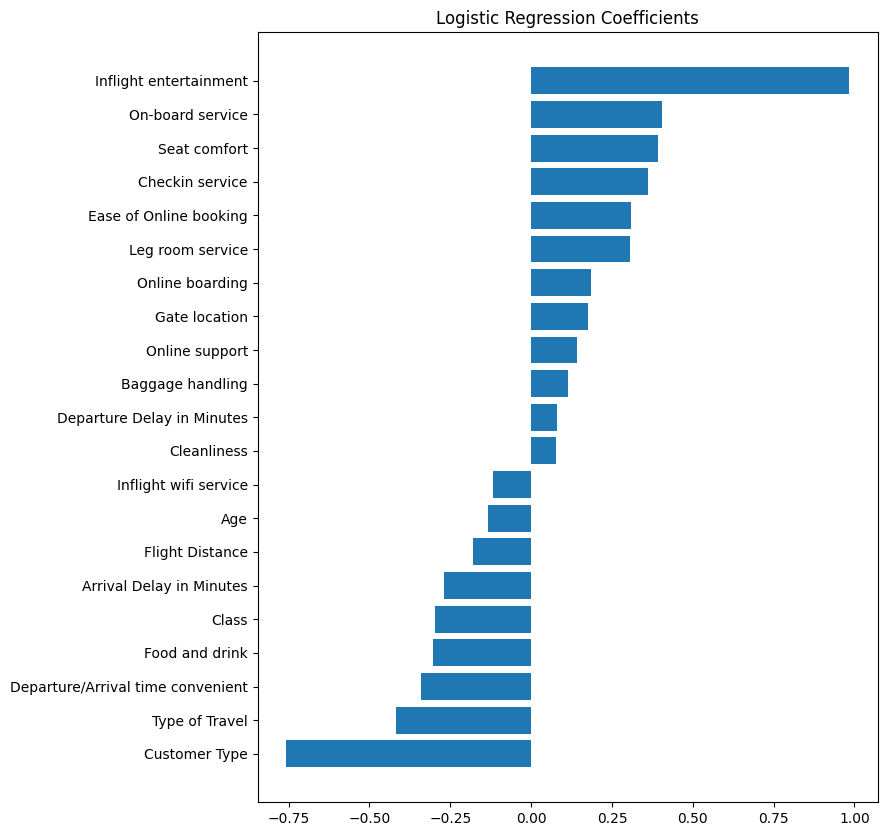

In [122]:
coefficients = coefficients.sort_values(by='Coefficient')

plt.figure(figsize=(8,10))

plt.barh(coefficients['Feature'], coefficients['Coefficient'])

plt.title("Logistic Regression Coefficients")

plt.show()

**Interpretation**

The table above presents the estimated coefficients from the Logistic Regression model, showing the direction and relative strength of each feature's association with passenger satisfaction. Positive coefficients indicate that higher values of a feature increase the likelihood that a passenger will be classified as **Satisfied**, while negative coefficients indicate a reduced likelihood of satisfaction.

Among all the predictors, **Inflight Entertainment** (0.984) is the strongest positive contributor to passenger satisfaction, suggesting that improvements in entertainment services are strongly associated with higher satisfaction levels. Other important positive factors include **On-board Service**, **Seat Comfort**, **Check-in Service**, **Ease of Online Booking**, and **Leg Room Service**, highlighting the importance of delivering a high-quality onboard and pre-flight experience.

On the other hand, **Customer Type** (-0.759) has the strongest negative coefficient. Based on the label encoding (Loyal Customer = 0, Disloyal Customer = 1), this indicates that **disloyal customers are less likely to be satisfied than loyal customers**. Similarly, **Type of Travel** (-0.419) suggests that **personal travelers are less likely to be satisfied than business travelers**, while the negative coefficient for **Class** (-0.298) indicates that passengers traveling in **Economy or Eco Plus** are generally less likely to report satisfaction than those traveling in **Business Class**.

Additionally, **Arrival Delay in Minutes** (-0.269) demonstrates that longer arrival delays reduce the likelihood of passenger satisfaction, emphasizing the importance of operational efficiency and on-time performance.

Overall, the model indicates that passenger satisfaction is primarily driven by the quality of onboard services, comfort, and customer loyalty. These findings provide valuable insights that can help airline management prioritize investments in service quality, customer retention programs, and operational improvements to enhance the overall passenger experience.


### Overall Business Interpretation

The Logistic Regression model achieved an **accuracy of 82.58%**, demonstrating good predictive performance in classifying passenger satisfaction. The analysis identified **Inflight Entertainment, On-board Service, Seat Comfort, Check-in Service,** and **Ease of Online Booking** as the strongest positive drivers of satisfaction. Conversely, **Disloyal Customer, Personal Travel, Economy Class,** and **Arrival Delay in Minutes** were associated with a lower likelihood of passenger satisfaction. These findings indicate that both service quality and operational efficiency play a critical role in shaping the overall passenger experience.

### Business Recommendations
* Invest in **in-flight entertainment, seat comfort, and onboard service**, as these are the strongest drivers of passenger satisfaction.
* Enhance the **digital customer experience**, particularly online booking and check-in processes, to improve convenience.
* Reduce **arrival delays** through better operational planning and scheduling to minimize passenger dissatisfaction.
* Strengthen **customer loyalty programs** to improve retention and increase satisfaction among frequent travelers.
* Develop targeted strategies for **personal and economy-class travelers**, who are less likely to report satisfaction, by improving service quality and offering value-added benefits.

### Model Limitations

The Logistic Regression model assumes a linear relationship between the predictor variables and the log-odds of the target variable, which may not capture more complex patterns in passenger satisfaction. Label encoding was used for categorical variables, which may introduce an artificial ordering for nominal categories such as travel class. Additionally, the model does not account for potential interactions between features. Future work could explore advanced classification algorithms such as Random Forest, Gradient Boosting, or XGBoost, along with one-hot encoding and hyperparameter tuning, to improve predictive performance.

### Conclusion

This project successfully developed and evaluated a Logistic Regression model for predicting airline passenger satisfaction. The model demonstrated strong performance across multiple evaluation metrics, including **82.58% accuracy**, **84.09% recall**, and balanced precision and F1-scores. The results show that service quality, customer loyalty, and operational performance are the primary factors influencing passenger satisfaction. These insights can support data-driven decisions that enhance customer experience, improve retention, and strengthen the airline's competitive advantage.
